# HW 2 Classifying Number of particles in dataset


<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<a href="https://colab.research.google.com/github/DeepTrackAI/DeepLearningCrashCourse/blob/main/Ch03_CNN/ec03_A_blood_smears/blood_smears.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
<strong>If using Colab/Kaggle:</strong> You need to uncomment the code in the cell below this one.
</div>

In [20]:
!pip install deeplay  # Uncomment if using Colab/Kaggle.

# Qn 1

## Loading the  simple dataset

### Loading the data file

In [4]:
from google.colab import files
uploaded = files.upload()

Saving simple_particle_dataset.pkl to simple_particle_dataset.pkl


In [60]:
import pickle

with open("simple_particle_dataset.pkl", "rb") as f:
    data = pickle.load(f)

print(data.keys())

dict_keys(['images', 'labels'])


### Verifying data is loaded

In [61]:
import numpy as np

images = np.array(data["images"])
labels = np.array(data["labels"])

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("First label:", labels[0])

Images shape: (10000, 64, 64)
Labels shape: (10000, 3)
First label: [ 1.         24.87654974 11.32670694]


### Building Data Class

In [62]:
import torch
from torch.utils.data import Dataset

class ParticleDataset(Dataset):
    def __init__(self, data):
        self.images = np.array(data["images"], dtype=np.float32)
        self.labels = np.array(data["labels"], dtype=np.float32)
        self.targets = self.labels[:, 0]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.targets[idx]

        image = torch.tensor(image).unsqueeze(0)
        label = torch.tensor([label], dtype=torch.float32)

        return image, label

### Dataset Sanity Check

In [63]:
dataset = ParticleDataset(data)

image, label = dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([1, 64, 64])
Label: tensor([1.])


## Train / Validation / Test Split

In [64]:
from torch.utils.data import random_split

n_total = len(dataset)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_set, val_set, test_set = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

print("Train:", len(train_set))
print("Validation:", len(val_set))
print("Test:", len(test_set))

Train: 7000
Validation: 1500
Test: 1500


### Data Loaders

In [65]:
train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=256, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=256, shuffle=False)

## CNN Architecture 1 (Baseline Model)
This model is the baseline convolutional neural network used for binary classification of the simple particle dataset. The architecture consists of two convolutional layers with 8 and 16 output channels respectively, each followed by a 2×2 max pooling operation. The feature maps are then flattened and passed through a fully connected layer with a single output, representing the probability of the presence of a particle.

A sigmoid activation function is applied to the output to produce a probability between 0 and 1. The model is trained using binary cross-entropy loss.

This architecture is relatively small, with a moderate number of trainable parameters, and is sufficient to capture the simple patterns present in the dataset. It serves as a reference model for comparing other architectural variations.

In [112]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Convolution layers
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        # Pooling
        self.pool = nn.MaxPool2d(2, 2)
        # Fully connected
        self.fc = nn.Linear(16 * 16 * 16, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)  # flatten
        x = torch.sigmoid(self.fc(x))

        return x

### Training set up

In [80]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Training loop

In [86]:
from sklearn.metrics import f1_score
import numpy as np

def evaluate(model, loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images).cpu().numpy().ravel()
            preds = (outputs >= 0.5).astype(int)

            y_pred.extend(preds)
            y_true.extend(labels.numpy().ravel().astype(int))

    return f1_score(y_true, y_pred)

In [87]:
def train_and_evaluate(model, train_loader, val_loader, test_loader, epochs=5):
    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    train_f1 = evaluate(model, train_loader)
    val_f1 = evaluate(model, val_loader)
    test_f1 = evaluate(model, test_loader)
    params = count_parameters(model)

    print("Train F1:", train_f1)
    print("Validation F1:", val_f1)
    print("Test F1:", test_f1)
    print("Parameters:", params)

    return model, train_f1, val_f1, test_f1, params

In [98]:
results = []


### Evaluation + F1 score + Parameter Count

In [113]:
print("=== BaselineCNN ===")
baseline_model = BaselineCNN()
baseline_model, train_f1, val_f1, test_f1, params = train_and_evaluate(
    baseline_model, train_loader, val_loader, test_loader, epochs=5
)
results.append({
    "Model": "BaselineCNN",
    "Train F1": train_f1,
    "Validation F1": val_f1,
    "Test F1": test_f1,
    "Parameters": params
})

=== BaselineCNN ===
Epoch 1, Loss: 8.4468
Epoch 2, Loss: 0.0215
Epoch 3, Loss: 0.0054
Epoch 4, Loss: 0.0021
Epoch 5, Loss: 0.0010
Train F1: 1.0
Validation F1: 1.0
Test F1: 1.0
Parameters: 5345


### ROC Curve

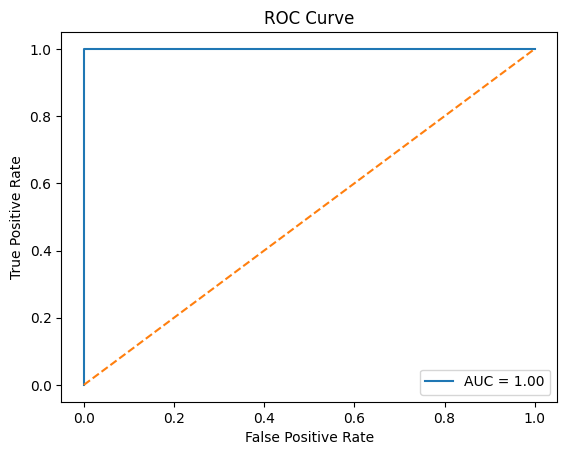

In [85]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc(model, loader):
    model.eval()

    y_true = []
    y_scores = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images).cpu().numpy().ravel()

            y_scores.extend(outputs)
            y_true.extend(labels.numpy().ravel())

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

plot_roc(baseline_model, test_loader)

Visualising predictions

In [43]:
print("Train F1:", evaluate(model, train_loader))
print("Validation F1:", evaluate(model, val_loader))
print("Test F1:", evaluate(model, test_loader))

Train F1: 1.0
Validation F1: 1.0
Test F1: 1.0


In [44]:
model.eval()

with torch.no_grad():
    images, labels = next(iter(test_loader))
    images = images.to(device)
    outputs = model(images).cpu().numpy().ravel()
    preds = (outputs >= 0.5).astype(int)

for i in range(10):
    print(f"True: {int(labels[i].item())}, Pred: {preds[i]}, Prob: {outputs[i]:.4f}")

True: 0, Pred: 0, Prob: 0.0000
True: 1, Pred: 1, Prob: 1.0000
True: 0, Pred: 0, Prob: 0.0000
True: 0, Pred: 0, Prob: 0.0000
True: 1, Pred: 1, Prob: 1.0000
True: 0, Pred: 0, Prob: 0.0000
True: 0, Pred: 0, Prob: 0.0000
True: 1, Pred: 1, Prob: 1.0000
True: 0, Pred: 0, Prob: 0.0000
True: 1, Pred: 1, Prob: 1.0000


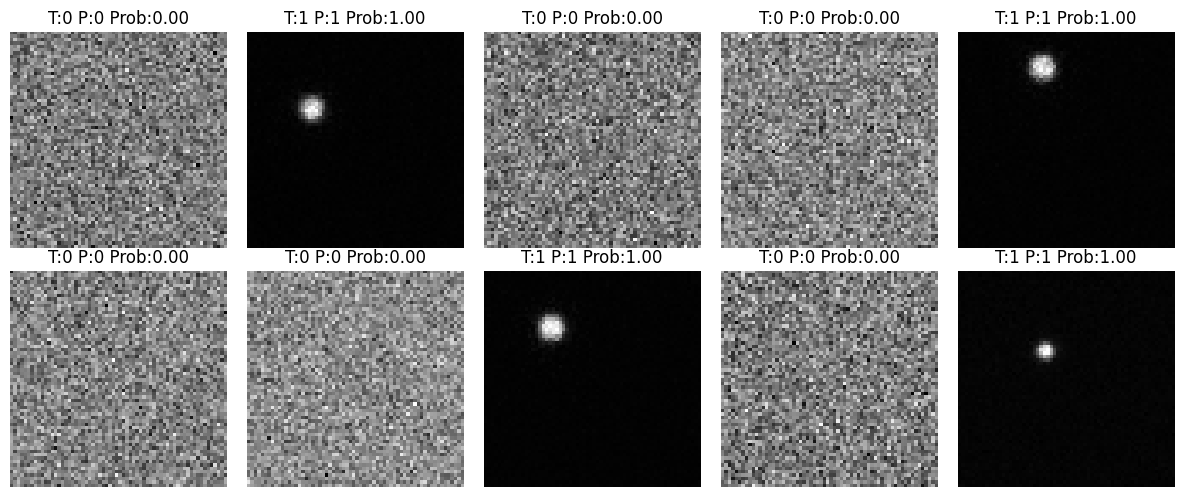

In [45]:
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
    images, labels = next(iter(test_loader))
    images_device = images.to(device)
    outputs = model(images_device).cpu().numpy().ravel()
    preds = (outputs >= 0.5).astype(int)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(images[i].squeeze(), cmap="gray")
    axes[i].set_title(f"T:{int(labels[i].item())} P:{preds[i]} Prob:{outputs[i]:.2f}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### Baseline model result
The baseline CNN achieved perfect performance on the simple particle dataset, with F1 = 1.0 on the training, validation, and test sets. Visual inspection of predictions confirmed that the model correctly separates background-only images from images containing a particle. This suggests that the simple dataset is highly separable for binary classification. The baseline model has 5345 trainable parameters.

## Architecture 2 (changing pool size 2x2 - 4x4)

This model modifies the baseline architecture by increasing the pooling window size from 2×2 to 4×4. The convolutional layers remain the same as in the baseline model, but the larger pooling operation reduces the spatial dimensions of the feature maps more aggressively.

As a result, the final feature map is much smaller, which significantly reduces the number of parameters in the fully connected layer. This leads to a more compact model overall.

However, the larger pooling operation also removes more spatial information, which may limit the model’s ability to detect fine details in more complex datasets. In the simple dataset, this reduction in detail does not significantly impact performance due to the high separability of the classes.

In [114]:
class PoolSizeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(4, 4)
        self.fc = nn.Linear(16 * 4 * 4, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 64 -> 16
        x = self.pool(F.relu(self.conv2(x)))   # 16 -> 4
        x = x.view(x.size(0), -1)
        x = torch.sigmoid(self.fc(x))
        return x

In [115]:
print("=== PoolSizeCNN ===")

PoolModel = PoolSizeCNN()
_, train_f1, val_f1, test_f1, params = train_and_evaluate(
    PoolModel, train_loader, val_loader, test_loader, epochs=5
)
results.append({
    "Model": "PoolSizeCNN",
    "Train F1": train_f1,
    "Validation F1": val_f1,
    "Test F1": test_f1,
    "Parameters": params
})

=== PoolSizeCNN ===
Epoch 1, Loss: 26.1139
Epoch 2, Loss: 0.1417
Epoch 3, Loss: 0.0430
Epoch 4, Loss: 0.0210
Epoch 5, Loss: 0.0123
Train F1: 1.0
Validation F1: 1.0
Test F1: 1.0
Parameters: 1505


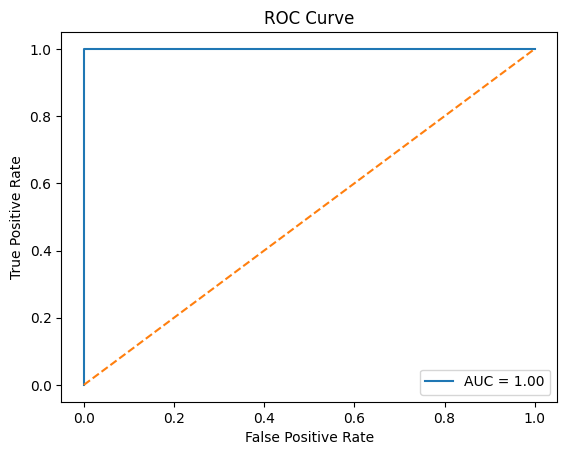

In [104]:

plot_roc(PoolModel, test_loader)

### Architecture 3 (Kernel Variation 3x3 - 5x5)


This model varies the baseline architecture by increasing the convolutional kernel size from 3×3 to 5×5. The number of convolutional layers and pooling operations remains unchanged.

The larger kernel size allows the model to capture a wider spatial context in each convolutional operation, enabling it to detect broader patterns in the input image. This can be useful for identifying larger structures or more diffuse features.

However, larger kernels also increase the number of trainable parameters and computational cost. In the context of the simple dataset, this additional complexity is not necessary, as the classification task is already easily solvable with smaller kernels.

In [116]:
class KernelCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(16 * 16 * 16, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 64 -> 32
        x = self.pool(F.relu(self.conv2(x)))   # 32 -> 16
        x = x.view(x.size(0), -1)
        x = torch.sigmoid(self.fc(x))
        return x

print("=== KernelCNN ===")
kernel_model = KernelCNN()
kernel_model, train_f1, val_f1, test_f1, params = train_and_evaluate(
    kernel_model, train_loader, val_loader, test_loader, epochs=5
)

results.append({
    "Model": "KernelCNN",
    "Train F1": train_f1,
    "Validation F1": val_f1,
    "Test F1": test_f1,
    "Parameters": params
})

=== KernelCNN ===
Epoch 1, Loss: 8.1756
Epoch 2, Loss: 0.0138
Epoch 3, Loss: 0.0058
Epoch 4, Loss: 0.0032
Epoch 5, Loss: 0.0020
Train F1: 1.0
Validation F1: 1.0
Test F1: 1.0
Parameters: 7521


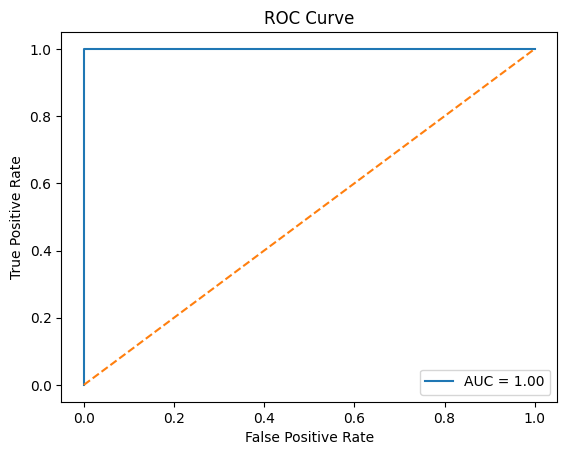

In [105]:

plot_roc(kernel_model, test_loader)

### Architecture 4 (Convolutional-layer)

This model varies the baseline architecture by increasing the convolutional kernel size from 3×3 to 5×5. The number of convolutional layers and pooling operations remains unchanged.

The larger kernel size allows the model to capture a wider spatial context in each convolutional operation, enabling it to detect broader patterns in the input image. This can be useful for identifying larger structures or more diffuse features.

However, larger kernels also increase the number of trainable parameters and computational cost. In the context of the simple dataset, this additional complexity is not necessary, as the classification task is already easily solvable with smaller kernels.

In [117]:
class OneConvCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(8 * 32 * 32, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 64 -> 32
        x = x.view(x.size(0), -1)
        x = torch.sigmoid(self.fc(x))
        return x

In [121]:
print("=== OneConvCNN ===")
OneConv_model = OneConvCNN()
OneConv_model, train_f1, val_f1, test_f1, params = train_and_evaluate(
    OneConv_model, train_loader, val_loader, test_loader, epochs=5
)

results.append({
    "Model": "OneConvCNN",
    "Train F1": train_f1,
    "Validation F1": val_f1,
    "Test F1": test_f1,
    "Parameters": params
})

=== OneConvCNN ===
Epoch 1, Loss: 8.9841
Epoch 2, Loss: 0.0905
Epoch 3, Loss: 0.0258
Epoch 4, Loss: 0.0121
Epoch 5, Loss: 0.0071
Train F1: 1.0
Validation F1: 1.0
Test F1: 1.0
Parameters: 8273


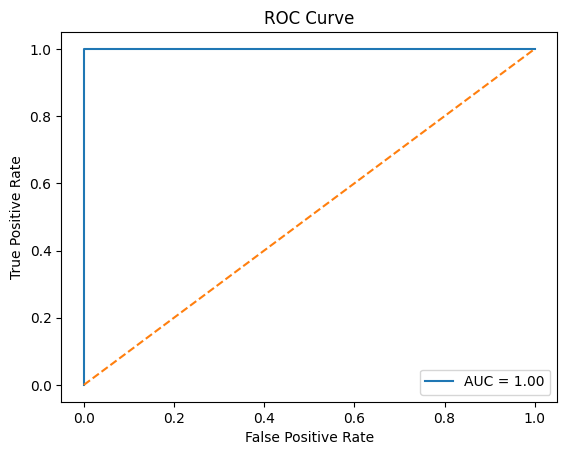

In [120]:
plot_roc(OneConv_model, test_loader)

### Smallest model
- convulution layer 1
- channels 1
- kernel size 1
- pool size 4

In [125]:
class BCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 1, kernel_size=1)
        self.pool = nn.MaxPool2d(4, 4)
        self.fc = nn.Linear(1 * 16 * 16, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)
        x = torch.sigmoid(self.fc(x))
        return x

In [124]:
b_model = BCNN()
b_model, train_f1, val_f1, test_f1, params = train_and_evaluate(
    b_model, train_loader, val_loader, test_loader, epochs=5
)

results.append({
    "Model": "bCNN",
    "Train F1": train_f1,
    "Validation F1": val_f1,
    "Test F1": test_f1,
    "Parameters": params
})

Epoch 1, Loss: 117.3556
Epoch 2, Loss: 64.2353
Epoch 3, Loss: 53.7336
Epoch 4, Loss: 45.7094
Epoch 5, Loss: 39.2122
Train F1: 1.0
Validation F1: 1.0
Test F1: 1.0
Parameters: 259


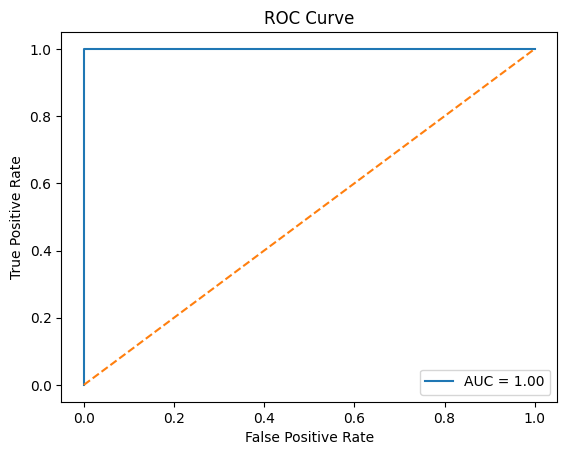

In [128]:
plot_roc(b_model, test_loader)

Compared with the baseline model, the extreme model uses only one convolution layer, one output channel, a 1×1 convolution kernel, and a larger 4×4 pooling operation. These changes greatly reduce the model capacity and the amount of spatial information retained. However, the model still achieved perfect F1 on the simple dataset, indicating that the task is highly separable.

In [126]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df

,Model,Train F1,Validation F1,Test F1,Parameters
0,BaselineCNN,1.0,1.0,1.0,5345
1,SmallerCNN,1.0,1.0,1.0,2385
2,TinyCNN,1.0,1.0,1.0,2069
3,PoolSizeCNN,1.0,1.0,1.0,1505
4,KernelCNN,1.0,1.0,1.0,7521
5,BaselineCNN,1.0,1.0,1.0,5345
6,BaselineCNN,1.0,1.0,1.0,5345
7,PoolSizeCNN,1.0,1.0,1.0,1505
8,KernelCNN,1.0,1.0,1.0,7521
9,OneConvCNN,1.0,1.0,1.0,7521


All tested architectures achieved F1 = 1.0 on the simple dataset, indicating that the classification task is highly separable. Even very small CNNs remained above the target threshold of 0.9.

#Q2

## Loading dataset

In [129]:
from google.colab import files
uploaded2 = files.upload()

Saving hard_particle_dataset.pkl to hard_particle_dataset.pkl


In [130]:
import pickle

with open("hard_particle_dataset.pkl", "rb") as f:
    data_hard = pickle.load(f)

print(data.keys())

dict_keys(['images', 'labels'])


### Inspecting the data

In [131]:
images = np.array(data_hard["images"])
labels = np.array(data_hard["labels"])

print(images.shape)
print(labels.shape)
print(labels[:5])

(12000, 64, 64)
(12000, 3)
[[ 3.         26.21856908 22.57383578]
 [ 3.         15.56853334 19.24209421]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 5.         17.50124658 22.95583488]]


### Number of classes

In [132]:
np.unique(labels[:, 0])

array([0., 1., 2., 3., 4., 5.])

In [141]:
hard_targets = hard_dataset.targets

for c in np.unique(hard_targets):
    print(f"Class {int(c)}:", np.sum(hard_targets == c))

Class 0: 2000
Class 1: 2000
Class 2: 2000
Class 3: 2000
Class 4: 2000
Class 5: 2000


### Build Dataset Classes

In [134]:
class HardParticleDataset(Dataset):
    def __init__(self, data):
        self.images = np.array(data["images"], dtype=np.float32)
        self.labels = np.array(data["labels"], dtype=np.float32)

        # Q2 target: number of particles, classes 0 to 5
        self.targets = self.labels[:, 0].astype(np.int64)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.targets[idx]

        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(label, dtype=torch.long)

        return image, label

### Splitting dataset and loaders

In [135]:
hard_dataset = HardParticleDataset(data_hard)

n_total = len(hard_dataset)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_set_hard, val_set_hard, test_set_hard = random_split(
    hard_dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader_hard = torch.utils.data.DataLoader(train_set_hard, batch_size=32, shuffle=True)
val_loader_hard = torch.utils.data.DataLoader(val_set_hard, batch_size=256, shuffle=False)
test_loader_hard = torch.utils.data.DataLoader(test_set_hard, batch_size=256, shuffle=False)

print(len(train_set_hard), len(val_set_hard), len(test_set_hard))

8400 1800 1800


### Multiclass evaluation using macro f1

In [138]:
from sklearn.metrics import f1_score

def evaluate_multiclass(model, loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    return f1_score(y_true, y_pred, average="macro")

### Training Function

In [139]:
def train_and_evaluate_multiclass(model, train_loader, val_loader, test_loader, epochs=5):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    train_f1 = evaluate_multiclass(model, train_loader)
    val_f1 = evaluate_multiclass(model, val_loader)
    test_f1 = evaluate_multiclass(model, test_loader)
    params = count_parameters(model)

    print("Train F1:", train_f1)
    print("Validation F1:", val_f1)
    print("Test F1:", test_f1)
    print("Parameters:", params)

    return model, train_f1, val_f1, test_f1, params

### Baseline Model

### BaselineCNN_Q2

This model is the direct extension of the baseline CNN from Question 1, adapted for multiclass classification. The architecture consists of two convolutional layers with 8 and 16 output channels respectively, each followed by a 2×2 max pooling operation. The feature maps are then flattened and passed through a fully connected layer with 6 outputs, corresponding to the six particle count classes (0–5).

Compared to the Question 1 model, the only change is in the output layer, which now produces 6 logits instead of a single probability. The model uses CrossEntropyLoss, so no sigmoid activation is applied to the final layer.

The total number of trainable parameters is relatively small, making this a simple baseline model. However, this simplicity limits its ability to capture the more complex patterns present in the hard dataset, leading to poor classification performance.

In [137]:
class BaselineCNN_Q2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(16 * 16 * 16, 6)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)   # no sigmoid here
        return x

In [152]:
print("=== Q2 BaselineCNN ===")
baseline_q2 = BaselineCNN_Q2()

baseline_q2, train_f1, val_f1, test_f1, params = train_and_evaluate_multiclass(
    baseline_q2,
    train_loader_hard,
    val_loader_hard,
    test_loader_hard,
    epochs=5
)
results.append({
    "Model": "BaselineCNN_Q2",
    "Train F1": train_f1,
    "Validation F1": val_f1,
    "Test F1": test_f1,
    "Parameters": params
})

=== Q2 BaselineCNN ===
Epoch 1, Loss: 500.4222
Epoch 2, Loss: 361.8895
Epoch 3, Loss: 332.1820
Epoch 4, Loss: 317.9603
Epoch 5, Loss: 300.4018
Train F1: 0.44862794034550907
Validation F1: 0.4365391870830005
Test F1: 0.4214999561343906
Parameters: 25830


However, it is evident that the model does not transfer well to the hard dataset.


### Architecture 2 (Deeper CNN)
This model extends the baseline architecture by increasing both the depth and the number of feature channels. It uses three convolutional layers instead of two, with channel sizes increasing from 16 to 32 to 64. Each convolutional layer is followed by a 2×2 max pooling operation, progressively reducing the spatial dimensions of the feature maps.

The deeper structure allows the network to learn more complex hierarchical features, which is important for distinguishing between images containing different numbers of particles. The final fully connected layer takes a reduced feature map of size 64×8×8 and outputs predictions for the 6 classes.

Compared to the baseline model, this architecture has significantly more trainable parameters and greater representational capacity. This makes it better suited for the harder multiclass classification task, where more detailed feature extraction is required.

In [143]:
print("=== Q2 DeeperCNN ===")

class DeeperCNN_Q2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(64 * 8 * 8, 6)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 64 → 32
        x = self.pool(F.relu(self.conv2(x)))   # 32 → 16
        x = self.pool(F.relu(self.conv3(x)))   # 16 → 8
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

deeper_model = DeeperCNN_Q2()

deeper_model, train_f1, val_f1, test_f1, params = train_and_evaluate_multiclass(
    deeper_model,
    train_loader_hard,
    val_loader_hard,
    test_loader_hard,
    epochs=10
)

results.append({
    "Model": "DeeperCNN_Q2",
    "Train F1": train_f1,
    "Validation F1": val_f1,
    "Test F1": test_f1,
    "Parameters": params
})

=== Q2 DeeperCNN ===
Epoch 1, Loss: 512.1729
Epoch 2, Loss: 471.9507
Epoch 3, Loss: 470.5741
Epoch 4, Loss: 470.5989
Epoch 5, Loss: 470.2604
Epoch 6, Loss: 467.6558
Epoch 7, Loss: 471.2638
Epoch 8, Loss: 471.2435
Epoch 9, Loss: 471.2438
Epoch 10, Loss: 471.2371
Train F1: 0.04891469055815711
Validation F1: 0.04788482789294377
Test F1: 0.044733044733044736
Parameters: 47878


### Architecture 3 (Kernel Size Variation)

This model modifies the baseline architecture by increasing the convolutional kernel size from 3×3 to 5×5. The network consists of two convolutional layers with 16 and 32 output channels respectively, each followed by 2×2 max pooling.

The larger kernel size allows each convolutional layer to capture a wider spatial context, meaning the model can consider a larger neighborhood of pixels when extracting features. This can be beneficial for detecting multiple particles or more spread-out structures within the image.

However, increasing the kernel size also increases the number of trainable parameters and computational cost. Compared to the baseline, this model is designed to test whether broader spatial feature extraction improves performance on the hard dataset.

In [144]:
print("=== Q2 Kernel5CNN ===")

class Kernel5CNN_Q2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(32 * 16 * 16, 6)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 64 → 32
        x = self.pool(F.relu(self.conv2(x)))   # 32 → 16
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

kernel_model = Kernel5CNN_Q2()

kernel_model, train_f1, val_f1, test_f1, params = train_and_evaluate_multiclass(
    kernel_model,
    train_loader_hard,
    val_loader_hard,
    test_loader_hard,
    epochs=10
)

results.append({
    "Model": "Kernel5CNN_Q2",
    "Train F1": train_f1,
    "Validation F1": val_f1,
    "Test F1": test_f1,
    "Parameters": params
})

=== Q2 Kernel5CNN ===
Epoch 1, Loss: 736.4202
Epoch 2, Loss: 471.2734
Epoch 3, Loss: 471.2515
Epoch 4, Loss: 471.2439
Epoch 5, Loss: 471.2425
Epoch 6, Loss: 471.2602
Epoch 7, Loss: 471.2485
Epoch 8, Loss: 471.2451
Epoch 9, Loss: 471.2475
Epoch 10, Loss: 471.2574
Train F1: 0.04843304843304844
Validation F1: 0.046663481446090144
Test F1: 0.044733044733044736
Parameters: 62406


### Architecture 4 (Reduced Pooling)
This model modifies the baseline architecture by increasing the convolutional kernel size from 3×3 to 5×5. The network consists of two convolutional layers with 16 and 32 output channels respectively, each followed by 2×2 max pooling.

The larger kernel size allows each convolutional layer to capture a wider spatial context, meaning the model can consider a larger neighborhood of pixels when extracting features. This can be beneficial for detecting multiple particles or more spread-out structures within the image.

However, increasing the kernel size also increases the number of trainable parameters and computational cost. Compared to the baseline, this model is designed to test whether broader spatial feature extraction improves performance on the hard dataset.

In [148]:
class LessPoolingCNN_Q2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)   # ← FIX ADDED
        self.fc = nn.Linear(32 * 32 * 32, 6)

    def forward(self, x):
        x = F.relu(self.conv1(x))        # 64 → 64
        x = self.pool(x)                 # 64 → 32
        x = F.relu(self.conv2(x))        # 32 → 32
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [150]:
print("=== Q2 LessPoolingCNN ===")

less_pool_model = LessPoolingCNN_Q2()

less_pool_model, train_f1, val_f1, test_f1, params = train_and_evaluate_multiclass(
    less_pool_model,
    train_loader_hard,
    val_loader_hard,
    test_loader_hard,
    epochs=10
)

results.append({
    "Model": "LessPoolingCNN_Q2",
    "Train F1": train_f1,
    "Validation F1": val_f1,
    "Test F1": test_f1,
    "Parameters": params
})

print("LessPoolingCNN_Q2 results")
print("Train F1:", train_f1)
print("Validation F1:", val_f1)
print("Test F1:", test_f1)
print("Parameters:", params)

=== Q2 LessPoolingCNN ===
Epoch 1, Loss: 3221.8656
Epoch 2, Loss: 471.5035
Epoch 3, Loss: 476.6478
Epoch 4, Loss: 471.7887
Epoch 5, Loss: 471.5550
Epoch 6, Loss: 471.4542
Epoch 7, Loss: 471.1991
Epoch 8, Loss: 471.1856
Epoch 9, Loss: 471.1148
Epoch 10, Loss: 471.1430
Train F1: 0.08689926132883992
Validation F1: 0.08372276753621684
Test F1: 0.08345246863395976
Parameters: 201414
LessPoolingCNN_Q2 results
Train F1: 0.08689926132883992
Validation F1: 0.08372276753621684
Test F1: 0.08345246863395976
Parameters: 201414


## Final Results


In [153]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df

,Model,Train F1,Validation F1,Test F1,Parameters
0,BaselineCNN,1.000000,1.000000,1.000000,5345
1,SmallerCNN,1.000000,1.000000,1.000000,2385
2,TinyCNN,1.000000,1.000000,1.000000,2069
3,PoolSizeCNN,1.000000,1.000000,1.000000,1505
4,KernelCNN,1.000000,1.000000,1.000000,7521
5,BaselineCNN,1.000000,1.000000,1.000000,5345
6,BaselineCNN,1.000000,1.000000,1.000000,5345
7,PoolSizeCNN,1.000000,1.000000,1.000000,1505
8,KernelCNN,1.000000,1.000000,1.000000,7521
9,OneConvCNN,1.000000,1.000000,1.000000,7521


Increasing model complexity did not improve performance on the hard dataset. In fact, larger models performed significantly worse than the baseline. This suggests that the models were not effectively learning from the data, possibly due to insufficient training or optimization difficulties.